In [2]:
import pandas as pd
import os

path = '/pasteur/u/rdcunha/data_cache/mmbu/final_data/subsampled_mmbu_data/final_cot_v2'
tsv = 'cls_closed.tsv'
# tsv2 = 'final_det/final_subsampled_det_grounding_open_1_7-v2.tsv'
tsv_path = os.path.join(path, tsv)
# tsv_path2 = os.path.join(path, tsv2)
df = pd.read_csv(tsv_path, sep='\t')
# df2 = pd.read_csv(tsv_path2, sep='\t')
# print(df.head())

/tmp/user/25210/ipykernel_3017288/2484023281.py:9: DtypeWarning: Columns (3,4,5,6,11,12,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tsv_path, sep='\t')


In [7]:
import pandas as pd
import os
import hashlib

# --- Configuration ---
BASE_DIR = '/pasteur/u/rdcunha/data_cache/mmbu/final_data/subsampled_mmbu_data'

TSV_FILES = [
    'final_cls/final_subsampled_cls_open_1_13_v2.tsv',
    'final_cls/final_subsampled_cls_closed_1_13_v2.tsv',
    # Uncomment the others if you want to process them now
    'final_det/final_subsampled_det_grounding_closed_1_13_v2.tsv',
    'final_det/final_subsampled_det_grounding_open_1_13_v2.tsv',
    'final_det/final_subsampled_det_guess_bbox_open_1_12_v2.tsv',
    'final_det/final_subsampled_det_guess_bbox_closed_1_12_v2.tsv',
    'final_seg/final_subsampled_seg_grounding_open_1_13_v2.tsv',
    'final_seg/final_subsampled_seg_grounding_closed_1_13_v2.tsv'
]

def generate_unique_hash(dataset, image_path):
    """
    Creates a deterministic SHA-256 hash for a dataset/image pair.
    """
    # 1. Sanitize inputs (convert to string, strip whitespace)
    # Handle NaN/None by converting to empty string or a placeholder if preferred
    d_str = str(dataset).strip() if pd.notna(dataset) else "UNKNOWN_DATASET"
    i_str = str(image_path).strip() if pd.notna(image_path) else "UNKNOWN_PATH"
    
    # 2. Concatenate with a separator
    combo = f"{d_str}|{i_str}"
    
    # 3. Hash the string
    return hashlib.sha256(combo.encode('utf-8')).hexdigest()

# --- Processing Loop ---
for relative_path in TSV_FILES:
    full_path = os.path.join(BASE_DIR, relative_path)
    
    if not os.path.exists(full_path):
        print(f"Skipping: {full_path} not found.")
        continue
        
    print(f"Processing: {relative_path}")
    
    # Load Data
    df = pd.read_csv(full_path, sep='\t')
    
    # Check if columns exist
    if 'dataset' not in df.columns or 'image_path' not in df.columns:
        print(f"  WARNING: Skipping {relative_path} (Missing 'dataset' or 'image_path' column)")
        continue
        
    # Apply Hashing
    # We use apply() row-wise
    df['unique_id'] = df.apply(lambda row: generate_unique_hash(row['dataset'], row['image_path']), axis=1)
    
    # Optional: Move unique_id to the front for better visibility?
    # cols = ['unique_id'] + [c for c in df.columns if c != 'unique_id']
    # df = df[cols]
    
    # Save back to the SAME path (overwriting)
    df.to_csv(full_path, sep='\t', index=False)
    
    print(f"  - Added unique_id to {len(df)} rows.")
    print(f"  - Saved.\n")

print("All files processed.")

Processing: final_cls/final_subsampled_cls_open_1_13_v2.tsv


/tmp/user/25210/ipykernel_3017288/533975421.py:46: DtypeWarning: Columns (3,4,5,6,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path, sep='\t')


  - Added unique_id to 21265 rows.
  - Saved.

Processing: final_cls/final_subsampled_cls_closed_1_13_v2.tsv


/tmp/user/25210/ipykernel_3017288/533975421.py:46: DtypeWarning: Columns (3,4,5,6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(full_path, sep='\t')


  - Added unique_id to 21265 rows.
  - Saved.

Processing: final_det/final_subsampled_det_grounding_closed_1_13_v2.tsv
  - Added unique_id to 4470 rows.
  - Saved.

Processing: final_det/final_subsampled_det_grounding_open_1_13_v2.tsv
  - Added unique_id to 4470 rows.
  - Saved.

Processing: final_det/final_subsampled_det_guess_bbox_open_1_12_v2.tsv
  - Added unique_id to 4238 rows.
  - Saved.

Processing: final_det/final_subsampled_det_guess_bbox_closed_1_12_v2.tsv
  - Added unique_id to 4238 rows.
  - Saved.

Processing: final_seg/final_subsampled_seg_grounding_open_1_13_v2.tsv
  - Added unique_id to 5250 rows.
  - Saved.

Processing: final_seg/final_subsampled_seg_grounding_closed_1_13_v2.tsv
  - Added unique_id to 5250 rows.
  - Saved.

All files processed.


In [6]:
# unique (metadata_modality, metadata_submodality) pairs
pairs = (
    df[["metadata_modality", "metadata_submodality"]]
    .astype("string")
    .drop_duplicates()
    .sort_values(["metadata_modality", "metadata_submodality"])
)

for mod, sub in pairs.itertuples(index=False):
    print(f"{mod}\t{sub}")

computed tomography	Conventional CT
computed tomography	Spiral CT
digital pathology	Brightfield Microscopy
electron microscopy	Serial Blockface SEM
electron microscopy	cryo-electron tomography
electron microscopy	serial blockface scanning electron microscopy
endoscopy	Confocal Laser Endomicroscopy
endoscopy	Laparoscopy
endoscopy	White-light Endoscopy
fluorescence microscopy	Brightfield Microscopy
fluorescence microscopy	Differential fluorescent microscopy
fluorescence microscopy	Epifluorescence Microscopy
fluorescence microscopy	Simulated Fluorescence Microscopy
fluorescence microscopy	confocal microscopy
fluorescence microscopy	epifluorescence microscopy
fluorescence microscopy	synthetic
fluorescence microscopy	total internal reflection fluorescence microscopy (TIRF)
light microscopy	B-Mode Ultrasound|Brightfield Microscopy|Dermoscopy|Optical Coherence Tomography|Digital Radiography|Fundus Photography|Conventional CT
light microscopy	Brightfield Microscopy
light microscopy	Differentia

In [2]:
df_na = df2[df2['metadata_submodality']=='Structural MRI']

In [10]:
df2['perceptual granularity'].unique()

array([nan, 'Image level', 'Box level', 'Mask level', 'Contour level'],
      dtype=object)

In [7]:
import ast
import numpy as np
import pandas as pd
import re

COL = "class_label"
assert COL in df.columns, f"df missing '{COL}'. Columns: {list(df.columns)}"

# Accept ints/floats (including strings that parse to numbers)
def _is_number(x):
    try:
        float(x)
        return True
    except Exception:
        return False

def is_bbox_list_str(s) -> bool:
    # Must be a string
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return False
    if not isinstance(s, str):
        return False

    t = s.strip()
    if not t:
        return False

    # Quick structural check: looks like [ ... ]
    if not (t.startswith("[") and t.endswith("]")):
        return False

    # Try literal_eval
    try:
        obj = ast.literal_eval(t)
    except Exception:
        return False

    # Must be list/tuple length 4
    if not isinstance(obj, (list, tuple)) or len(obj) != 4:
        return False

    # Each element must be numeric-ish
    if not all(_is_number(x) for x in obj):
        return False

    return True

mask_bad = ~df[COL].apply(is_bbox_list_str)

bad_rows = df.loc[mask_bad, [COL]].copy()
print(f"Bad rows: {mask_bad.sum()} / {len(df)}")

# Show a sample + indices
display(bad_rows.head(50))

# If you want the exact indices list:
bad_indices = bad_rows.index.tolist()
bad_indices[:50]

Bad rows: 89 / 3228


,class_label
2767,"[[239, 401, 42, 32], [194, 385, 42, 32], [251,..."
2768,"[[115, 56, 64, 28], [30, 240, 49, 34], [404, 4..."
2772,"[[449, 216, 42, 44], [379, 253, 32, 42]]"
2776,"[[315, 216, 40, 43], [79, 316, 40, 40], [426, ..."
2779,"[[280, 96, 36, 35], [120, 32, 34, 35], [229, 1..."
2782,"[[449, 306, 40, 36], [64, 87, 29, 24]]"
2783,"[[309, 48, 48, 48], [271, 352, 45, 49]]"
2785,"[[394, 230, 44, 50], [257, 432, 45, 46], [203,..."
2808,"[[15, 0, 126, 176], [253, 248, 150, 187]]"
2841,"[[150, 80, 35, 32], [397, 111, 35, 34]]"


[2767,
 2768,
 2772,
 2776,
 2779,
 2782,
 2783,
 2785,
 2808,
 2841,
 2848,
 2849,
 2850,
 2851,
 2852,
 2853,
 2854,
 2855,
 2856,
 2857,
 2861,
 2862,
 2865,
 2867,
 2868,
 2878,
 2879,
 2883,
 2884,
 2885,
 2887,
 2908,
 2909,
 2910,
 2911,
 2912,
 2913,
 2914,
 2915,
 2916,
 2917,
 3002,
 3003,
 3004,
 3008,
 3009,
 3010,
 3011,
 3015,
 3016]

instrument shaft, instrument clasper, instrument wrist, kidney parenchyma, covered kidney, suturing needle, suction instrument, small-intestine, ultrasound_probe
instrument shaft, instrument clasper, instrument wrist, kidney parenchyma, covered kidney, suturing needle, suction instrument, small-intestine, ultrasound_probe
/pasteur/u/rdcunha/data_cache/mmbu/final_data/VLMEvalData_v2/LMUData/seg/endoscopy/EndoVis_2018_RSS/overlayed_images/train/seq_3_frame082.jpg


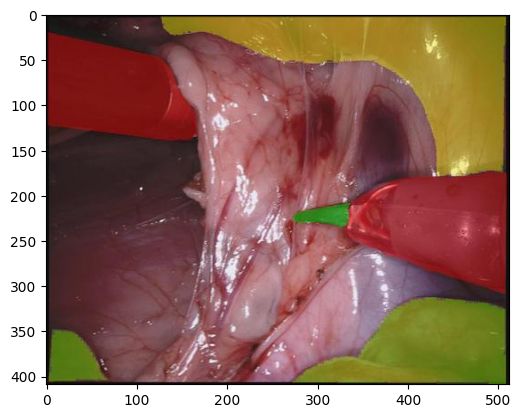

In [42]:
import matplotlib.pyplot as plt
from PIL import Image
row = df2.iloc[2100]
print(row['answer'])
print(row['class_label'])
# print(row['options'])
print(row['image_path'])
row_img = row['image_path']
img = Image.open(row_img)
plt.imshow(img)

In [33]:
df_cls['answer'].unique()

array(['D', 'A', 'B', 'C', 'ABCDEG', 'ABCDEF', 'ABCDEFJKLM', 'ADEF',
       'ABCDEFGHI', 'ABCD', 'ABCDE', 'ABCDJKL', 'AGHIJ', 'ABDGHIJK',
       'ABCDEFIJK', 'ABCDHIJK', 'ABCDEGHI', 'ABCDEFGH', 'ABCDIJKLM',
       'ABCDEFGHIJKLM', 'ABCDFHIJKL', 'ACDE', 'ABCDEFG', 'ACDEFG',
       'ABDEFGHIJK', 'AGHI', 'ACDEFJKLM', 'ACDEFGH', 'ABC', 'ABD',
       'ABCDEFIJKLM', 'ABCDEIJKL', 'ABDEFGIJK', 'ABCDEFHIK', 'G',
       'ABCDIJK', 'ABCDJKLM', 'ABCDEHIJ', 'ABCEGI', 'ABCIJKLM', 'ABDEF',
       'ABCDEFGIJKLM', 'AFGH', 'ABEG', 'ABCDGHIJKLM', 'ABCDEHIK', 'J',
       'AEFG', 'ACDEF', 'AHIJ', 'ABCJKLM', 'AHIJK', 'ACDEFGHIJ', 'AB',
       'ADEFGH', 'ABCDEIJK', 'ABCDFGH', 'ABHJ', 'ABDHIJKL',
       'ABCDEFGHIJKL', 'ABCDEIJKLM', 'ABEFG', 'ABCDKLM', 'ABCDEJKLM',
       'ACDEFGHIJK', 'ABEFGH', 'ABCDEGHIJ', 'ABCDEFGHIKL', 'AEFGH',
       'ABFGH', 'ABCDEFGHIJK', 'ABDEFH', 'ABCEG', 'ABCDEIK', 'CD',
       'ABCDEFGIJK', 'ABDEFIJKLM', 'ABCDEGI', 'AGI', 'ABCEFGHIJK',
       'ADEFIJK', 'ABEFGHI', 'ABCEFGH', 'ABDEF

In [19]:
import pandas as pd
import os

path = '/pasteur/u/rdcunha/data_cache/mmbu/final_data/subsampled_mmbu_data'
tsv = 'final_det/final_subsampled_det_guess_bbox_open_12_29-v2.tsv'
tsv_path = os.path.join(path, tsv)
df = pd.read_csv(tsv_path, sep='\t')
df['class_label'] = df['answer']
df.to_csv()

In [20]:
df['class_label']

0          [8, 38, 233, 433]
1         [21, 36, 202, 336]
2         [34, 22, 169, 414]
3        [38, 110, 193, 316]
4         [23, 18, 172, 305]
                ...         
3223    [104, 128, 196, 278]
3224        [0, 0, 417, 509]
3225        [0, 0, 417, 509]
3226     [140, 87, 224, 300]
3227     [140, 87, 224, 300]
Name: class_label, Length: 3228, dtype: object

# Look at model outputs

In [3]:
import pandas as pd
import os

input_path = '/pasteur/u/rdcunha/code/mmbu/results/Qwen3-VL-4B-Instruct/Qwen3-VL-4B-Instruct_detection_grounding_closed_VQA.jsonl'

# 'lines=True' tells pandas that the file is line-delimited JSON
df = pd.read_json(input_path, lines=True)

if 'index' in df.columns and 'answer' in df.columns:
    df_subset = df[['index', 'answer']]

In [4]:
df_subset.head()

,index,answer
0,0,B) Left Lung
1,1,C) Left Lung
2,2,A) Left Lung
3,3,B) Right Lung
4,4,B) Left Lung


In [7]:
from pathlib import Path
import json

ROOT = Path("/pasteur/u/rdcunha/code/mmbu/results/")
SUBSTR = "detection_grounding_closed"   # only files containing this
EXT = ".jsonl"

bad_models = []          # list of (model_name, file_name, first_index)
missing_models = []      # model folders with no matching file
parse_errors = []        # list of (model_name, file_name, error)

def read_first_json_obj(jsonl_path: Path):
    """Return first valid JSON object from a jsonl file (skipping blank lines)."""
    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            return json.loads(line)
    return None  # empty file

for model_dir in sorted([p for p in ROOT.iterdir() if p.is_dir()]):
    model_name = model_dir.name
    matches = sorted([p for p in model_dir.iterdir() if p.is_file() and (SUBSTR in p.name) and p.name.endswith(EXT)])

    if not matches:
        missing_models.append(model_name)
        continue

    for fp in matches:
        try:
            first_obj = read_first_json_obj(fp)
            if first_obj is None:
                parse_errors.append((model_name, fp.name, "empty file"))
                continue

            if "index" not in first_obj:
                parse_errors.append((model_name, fp.name, "missing 'index' field in first JSONL entry"))
                continue

            first_idx = first_obj["index"]
            if first_idx != 0:
                bad_models.append((model_name, fp.name, first_idx))

        except Exception as e:
            parse_errors.append((model_name, fp.name, f"{type(e).__name__}: {e}"))

# ---- Report ----
print(f"Checked model folders in: {ROOT}")
print(f"Target files contain: '{SUBSTR}' and end with '{EXT}'\n")

print(f"Models whose first JSONL entry does NOT start at index=0: {len(bad_models)}")
for m, fn, idx in bad_models:
    print(f"  - {m}: {fn} (first index = {idx})")

print(f"\nModel folders with NO matching file: {len(missing_models)}")
for m in missing_models[:50]:
    print(f"  - {m}")
if len(missing_models) > 50:
    print(f"  ... and {len(missing_models) - 50} more")

print(f"\nFiles with parse/schema issues: {len(parse_errors)}")
for m, fn, err in parse_errors[:50]:
    print(f"  - {m}: {fn} -> {err}")
if len(parse_errors) > 50:
    print(f"  ... and {len(parse_errors) - 50} more")

Checked model folders in: /pasteur/u/rdcunha/code/mmbu/results
Target files contain: 'detection_grounding_closed' and end with '.jsonl'

Models whose first JSONL entry does NOT start at index=0: 11
  - InternVL3_5-8B: InternVL3_5-8B_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Lingshu-32B: Lingshu-32B_detection_grounding_closed_VQA.jsonl (first index = 22)
  - MedVLM-R1: MedVLM-R1_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Qwen2-VL-2B-Instruct: Qwen2-VL-2B-Instruct_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Qwen2.5-VL-32B-Instruct: Qwen2.5-VL-32B-Instruct_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Qwen3-VL-32B-Instruct: Qwen3-VL-32B-Instruct_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Qwen3-VL-32B-Thinking: Qwen3-VL-32B-Thinking_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Qwen3-VL-4B-Thinking: Qwen3-VL-4B-Thinking_detection_grounding_closed_VQA.jsonl (first index = 22)
  - Qwen3-VL-8B-Inst

# Update Path, SLAKE, rad

In [6]:
import pandas as pd

path = '/pasteur/u/rdcunha/code/mmbu/src/analysis/assets/trad_results.csv'
df = pd.read_csv(path)

In [4]:
new_row = {"model_name":'OctoMed-7B', "VQA-RAD": 85.66, "SLAKE": 89.66, "PathVQA": 0.0, "PMC-VQA": 0.0}
new_row_df = pd.DataFrame([new_row])
df = pd.concat([df, new_row_df], ignore_index=True)
df

,model_name,VQA-RAD,SLAKE,PathVQA,PMC-VQA
0,BiomedGPT,16.60,13.60,11.3,27.6
1,Med-R1-2B,39.00,54.50,15.3,47.4
2,MedVLM-R1,48.60,56.00,32.5,47.6
3,medgemma-4b-it,72.50,76.40,48.8,49.9
4,gemma-3-4b-it,48.70,43.00,0.0,0.0
5,llava-med-v1.5-mistral-7b,53.70,48.00,38.8,30.5
6,HuatuoGPT-V-7B,67.00,67.80,48.0,53.3
7,BioMediX2-8B,49.20,57.70,37.0,43.5
8,Qwen2.5-VL-7B-Instruct,64.50,67.20,44.1,51.9
9,InternVL2.5-8B,59.40,69.00,42.1,51.3


In [5]:
df.to_csv(path, index=False)